**Overview**

This dataset Imports-85 contains 206 car instances (rows) described by 26 attributes. It was designed to predict the price of imported cars based on a combination of technical specifications, insurance risk ratings, and manufacturer details.


**Attribute Summary**

| Attribute               | Description                                    | Type                                 | Interpretation / Relevance                                                                                         |
| ----------------------- | ---------------------------------------------- | ------------------------------------ | --------------------------------------------------------------------- |
| 1. `symboling`          | Insurance risk rating (-3 to +3)               | Integer                              | Higher value = higher risk of accident (used by insurance companies). |
| 2. `normalized-losses`  | Average loss per insured vehicle               | Continuous (can be missing)          | Proxy for repair cost and reliability.                                |
| 3. `make`               | Car brand (e.g., Alfa-Romeo, BMW, Toyota)      | Categorical                          | Useful for brand-level price clustering or encoding.                  |
| 4. `fuel-type`          | Gas or diesel                                  | Categorical                          | Can influence mileage, torque, and maintenance cost.                  |
| 5. `aspiration`         | Standard or turbo                              | Categorical                          | Turbo engines often yield higher performance and price.               |
| 6. `num-of-doors`       | Two or four                                    | Categorical                          | Related to vehicle size and segment.                                  |
| 7. `body-style`         | sedan, hatchback, convertible, etc.            | Categorical                          | Impacts price and perceived utility.                                  |
| 8. `drive-wheels`       | FWD, RWD, 4WD                                  | Categorical                          | Affects traction and price; performance vs. economy trade-off.        |
| 9. `engine-location`    | Front or rear                                  | Categorical                          | Engineering choice—most are front-engine.                             |
| 10. `wheel-base`        | Distance between axles                         | Continuous                           | Larger wheelbase = better stability, often higher price.              |
| 11. `length`            | Overall vehicle length (in inches)             | Continuous                           | Proxy for car segment (compact vs. luxury).                           |
| 12. `width`             | Vehicle width                                  | Continuous                           | Wider cars generally more comfortable/luxurious.                      |
| 13. `height`            | Vehicle height                                 | Continuous                           | Minor effect, but part of dimensional analysis.                       |
| 14. `curb-weight`       | Weight without passengers/cargo                | Continuous                           | Heavier cars often have bigger engines and higher prices.             |
| 15. `engine-type`       | dohc, ohcv, ohc, rotor, etc.                   | Categorical                          | Reflects mechanical design differences.                               |
| 16. `num-of-cylinders`  | Two to twelve                                  | Categorical (convertible to numeric) | More cylinders → greater power → higher price.                        |
| 17. `engine-size`       | Engine displacement (cc)                       | Continuous                           | Major predictor of horsepower and price.                              |
| 18. `fuel-system`       | mpfi, 2bbl, spfi, etc.                         | Categorical                          | Describes fuel injection mechanism; affects efficiency.               |
| 19. `bore`              | Cylinder diameter                              | Continuous                           | Used in engine performance calculations.                              |
| 20. `stroke`            | Piston stroke length                           | Continuous                           | Along with bore, defines displacement and torque.                     |
| 21. `compression-ratio` | Ratio of cylinder volume to combustion chamber | Continuous                           | Higher ratio = efficiency but risk of knocking.                       |
| 22. `horsepower`        | Engine power (hp)                              | Continuous                           | Strong positive correlation with price.                               |
| 23. `peak-rpm`          | Engine speed at max power                      | Continuous                           | Higher peak-rpm = sportier engine.                                    |
| 24. `city-mpg`          | Mileage in city conditions                     | Continuous                           | Inversely correlated with engine size and price.                      |
| 25. `highway-mpg`       | Mileage on highways                            | Continuous                           | Complements city-mpg; higher values indicate efficiency.              |
| 26. `price`             | Car’s market price (target variable)           | Continuous                           | The dependent variable for regression/classification.                 |


**Insights and Interpretations**

1.	Economic vs. Performance Trade-off:
Cars with larger engines (engine-size, horsepower, curb-weight) generally have lower mpg but higher price, revealing the classic performance–economy trade-off.
2.	Categorical Influence:
Attributes like fuel-type, aspiration, drive-wheels, and body-style serve as qualitative indicators of performance category—useful for encoding in SVM or decision trees.
3.	Manufacturer Effect:
Brands like BMW, Jaguar, and Mercedes cluster in the upper price range, while Honda, Toyota, and Nissan cluster lower, showing strong brand premium segmentation.
4.	Missing Data Treatment:
Variables such as normalized-losses and price have missing entries—these require imputation or removal depending on the modeling strategy.
5.	Variable Scaling:
Continuous variables (wheelbase, length, weight, horsepower) differ vastly in scale—standardization is essential for SVC to prevent dominance by high-magnitude features.
6.	Correlation Patterns:
Price correlates most strongly with engine-size, curb-weight, horsepower, and width, making them key predictors for model building.


In [38]:
# --- Step 1: Load the Dataset ---
import pandas as pd
df = pd.read_csv("/content/imports-85.csv")

In [39]:
df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    int64  
 16  engine-size        205 non

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [40]:
# Create a copy of the original DataFrame
df_clean = df.copy()

In [41]:
df_clean.info()
df_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    int64  
 16  engine-size        205 non

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [42]:
# --- Step 2: Data Cleaning – Handling Missing and Invalid Price Values ---
import numpy as np
import pandas as pd

# Standardize missing values and convert 'price' to numeric
df_clean.replace('?', np.nan, inplace=True)
df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')

# Remove rows with missing 'price' values
print("\n--- Handling Missing 'price' Values ---")
initial_count = len(df_clean)
print(f"Initial rows: {initial_count}")

df_clean.dropna(subset=['price'], inplace=True)

# Display results and updated DataFrame info
final_count = len(df_clean)
print(f"Rows removed: {initial_count - final_count}")
print(f"Rows remaining: {final_count}\n")
print("Updated DataFrame Info:")
df_clean.info()


--- Handling Missing 'price' Values ---
Initial rows: 205
Rows removed: 4
Rows remaining: 201

Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       199 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-

In [43]:
# --- Step 3 : Analyze Missing Data ---
# Calculate the percentage of missing values for each column
missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100

# Filter only the columns that have missing values and sort them in descending order
missing_percentage_sorted = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

# Display the results
print("\n--- Percentage of Missing Values by Column ---")
print(missing_percentage_sorted)



--- Percentage of Missing Values by Column ---
normalized-losses    18.407960
bore                  1.990050
stroke                1.990050
num-of-doors          0.995025
horsepower            0.995025
peak-rpm              0.995025
dtype: float64


Number of columns with missing values: 6
Columns containing missing data:
['normalized-losses', 'num-of-doors', 'bore', 'stroke', 'horsepower', 'peak-rpm']


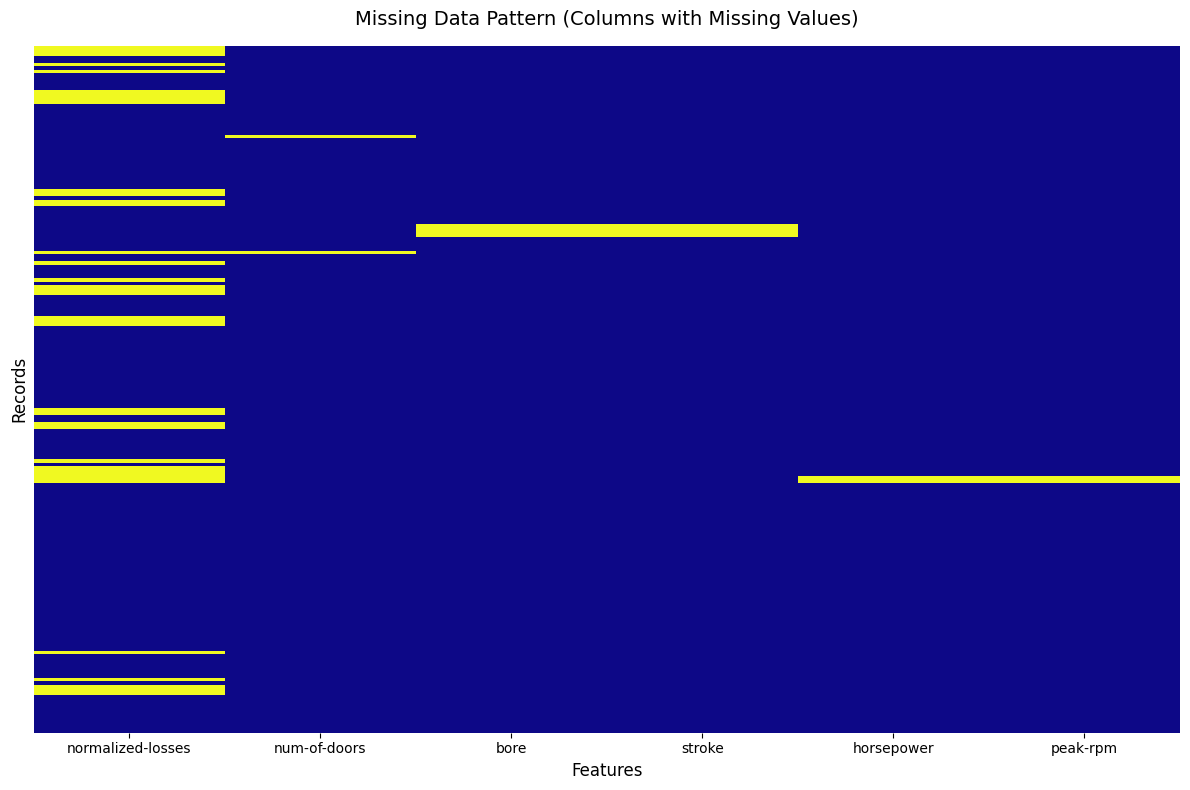

In [44]:
# --- Step 4: Visualize Missing Data Pattern Using Heatmap ---

# Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Identify columns that contain missing values
cols_with_missing = df_clean.columns[df_clean.isnull().any()].tolist()
df_missing = df_clean[cols_with_missing]

# Display basic info
print(f"Number of columns with missing values: {len(cols_with_missing)}")
print("Columns containing missing data:")
print(cols_with_missing)

# --- Create a Heatmap for Missing Data ---
plt.figure(figsize=(12, 8))
sns.heatmap(
    df_missing.isnull(),
    cbar=False,
    cmap='plasma', # Changed colormap
    yticklabels=False  # Hides row labels for clarity
)

# Add descriptive titles and labels
plt.title('Missing Data Pattern (Columns with Missing Values)', fontsize=14, pad=15)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Records', fontsize=12)
plt.tight_layout()

# Display the heatmap
plt.show()

In [45]:
# --- Step 5: Remove Rows with Missing 'bore' or 'horsepower' Values ---

# Record the initial number of rows
initial_rows = len(df_clean)
print(f"Initial row count: {initial_rows}")

# Drop rows where either 'bore' or 'horsepower' has missing values
df_clean.dropna(subset=['bore', 'horsepower'], inplace=True)

# Calculate and display the number of rows removed
rows_removed = initial_rows - len(df_clean)
print(f"Rows removed (due to missing 'bore' or 'horsepower'): {rows_removed}")
print(f"Rows remaining after cleanup: {len(df_clean)}")

# Display updated DataFrame information
print("\nUpdated DataFrame Info:")
df_clean.info()

Initial row count: 201
Rows removed (due to missing 'bore' or 'horsepower'): 6
Rows remaining after cleanup: 195

Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          195 non-null    int64  
 1   normalized-losses  160 non-null    float64
 2   make               195 non-null    object 
 3   fuel-type          195 non-null    object 
 4   aspiration         195 non-null    object 
 5   num-of-doors       193 non-null    object 
 6   body-style         195 non-null    object 
 7   drive-wheels       195 non-null    object 
 8   engine-location    195 non-null    object 
 9   wheel-base         195 non-null    float64
 10  length             195 non-null    float64
 11  width              195 non-null    float64
 12  height             195 non-null    float64
 13  curb-weight        195 non-null    in

In [46]:
# --- Step 6: Verify Remaining Missing Values ---

# Calculate the percentage of missing values in each column
missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

# Display results
if missing_percentage.empty:
    print("\nNo missing values remain in the dataset.")
else:
    print("\nColumns still containing missing values:")
    print(missing_percentage)


Columns still containing missing values:
normalized-losses    17.948718
num-of-doors          1.025641
dtype: float64


In [47]:
df_clean.head(3)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0


In [48]:
# --- Step 7: Analyze the Distribution of 'num-of-doors' ---

# Calculate the frequency of each unique category
door_counts = df_clean['num-of-doors'].value_counts()

# Calculate the percentage distribution (excluding missing values)
door_percentage = (door_counts / df_clean['num-of-doors'].count()) * 100

# Display results
print("\n--- Frequency Distribution of 'num-of-doors' ---")
print(door_counts)

print("\n--- Percentage Distribution of 'num-of-doors' ---")
print(door_percentage.round(2).astype(str) + '%')


--- Frequency Distribution of 'num-of-doors' ---
num-of-doors
four    112
two      81
Name: count, dtype: int64

--- Percentage Distribution of 'num-of-doors' ---
num-of-doors
four    58.03%
two     41.97%
Name: count, dtype: object


In [49]:

# --- Step 8: KNN Imputation for 'num-of-doors ---'

# This step performs K-Nearest Neighbors (KNN) imputation to fill missing values
# in the 'num-of-doors' column using all numeric features in the dataset.

# --- Import required libraries ---
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer

# --- Step 8.1: Prepare the 'num-of-doors' column ---
# Convert string values ('two', 'four') to numeric values (2, 4)
door_mapping = {'two': 2, 'four': 4}
df_clean['num-of-doors'] = df_clean['num-of-doors'].replace(door_mapping)

# Identify all numeric columns to be used as features for KNN imputation
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
df_impute = df_clean[numeric_cols].copy()

# --- Step 8.2: Apply KNN Imputer ---
k_value = 5  # Number of neighbors for KNN
imputer = KNNImputer(n_neighbors=k_value)

# Fit the imputer and transform the numeric DataFrame
df_impute_filled = imputer.fit_transform(df_impute)

# Convert the NumPy array back to a DataFrame with the original column names
df_impute_filled = pd.DataFrame(df_impute_filled, columns=numeric_cols, index=df_clean.index)

# --- Step 8.3: Update the 'num-of-doors' column ---
# Round the imputed values to the nearest integer (2 or 4)
df_clean['num-of-doors'] = df_impute_filled['num-of-doors'].round().astype(int)

# --- Step 8.4: Verify the imputation ---
print("Imputation of 'num-of-doors' complete.")
print("\nFinal unique values in 'num-of-doors':", df_clean['num-of-doors'].unique())
print("Missing values remaining:", df_clean['num-of-doors'].isnull().sum())


Imputation of 'num-of-doors' complete.

Final unique values in 'num-of-doors': [2 4 3]
Missing values remaining: 0


/tmp/ipython-input-1503253187.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['num-of-doors'] = df_clean['num-of-doors'].replace(door_mapping)


In [50]:
# --- Step 9: Count and Percentage of 'num-of-doors' Categories ---

# Calculate the count of each unique category in 'num-of-doors'
category_counts = df_clean['num-of-doors'].value_counts()

# Calculate the percentage of each category (excluding missing values)
category_percentage = (category_counts / df_clean['num-of-doors'].count()) * 100

# Display the counts
print("--- Counts for 'num-of-doors' ---")
print(category_counts)

# Display the percentage distribution (rounded to 2 decimals with '%' symbol)
print("\n--- Percentage Distribution for 'num-of-doors' ---")
print(category_percentage.round(2).astype(str) + '%')


--- Counts for 'num-of-doors' ---
num-of-doors
4    113
2     81
3      1
Name: count, dtype: int64

--- Percentage Distribution for 'num-of-doors' ---
num-of-doors
4    57.95%
2    41.54%
3     0.51%
Name: count, dtype: object


In [51]:
# --- Step 10: Enforce Valid Values in 'num-of-doors' ---

# Calculate the mode (most frequent value) among valid door counts (2 and 4)
# .mode()[0] returns the first mode, which is the most common value
door_mode = df_clean['num-of-doors'].mode()[0]

# Replace any invalid value (e.g., 3) with the calculated mode
df_clean['num-of-doors'].replace({3: door_mode}, inplace=True)

# Display the updated counts after enforcing valid constraints
print("--- Category Counts After Constraint Enforcement ---")
print(df_clean['num-of-doors'].value_counts())


--- Category Counts After Constraint Enforcement ---
num-of-doors
4    114
2     81
Name: count, dtype: int64


/tmp/ipython-input-2260890689.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['num-of-doors'].replace({3: door_mode}, inplace=True)


In [52]:
# --- Step 11: Display Updated DataFrame Information ---

print("\n--- Updated DataFrame Overview ---")
df_clean.info()



--- Updated DataFrame Overview ---
<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          195 non-null    int64  
 1   normalized-losses  160 non-null    float64
 2   make               195 non-null    object 
 3   fuel-type          195 non-null    object 
 4   aspiration         195 non-null    object 
 5   num-of-doors       195 non-null    int64  
 6   body-style         195 non-null    object 
 7   drive-wheels       195 non-null    object 
 8   engine-location    195 non-null    object 
 9   wheel-base         195 non-null    float64
 10  length             195 non-null    float64
 11  width              195 non-null    float64
 12  height             195 non-null    float64
 13  curb-weight        195 non-null    int64  
 14  engine-type        195 non-null    object 
 15  num-of-cylinders   195 non-null    int64  


In [53]:
# --- Step 12: Descriptive Statistics for 'normalized-losses' ---

# Calculate mean and standard deviation (ignoring NaN values automatically)
losses_mean = df_clean['normalized-losses'].mean()
losses_std = df_clean['normalized-losses'].std()

# Display the results
print("--- Descriptive Statistics for 'normalized-losses' ---")
print(f"Mean: {losses_mean:.2f}")
print(f"Standard Deviation: {losses_std:.2f}")


--- Descriptive Statistics for 'normalized-losses' ---
Mean: 121.30
Standard Deviation: 35.60


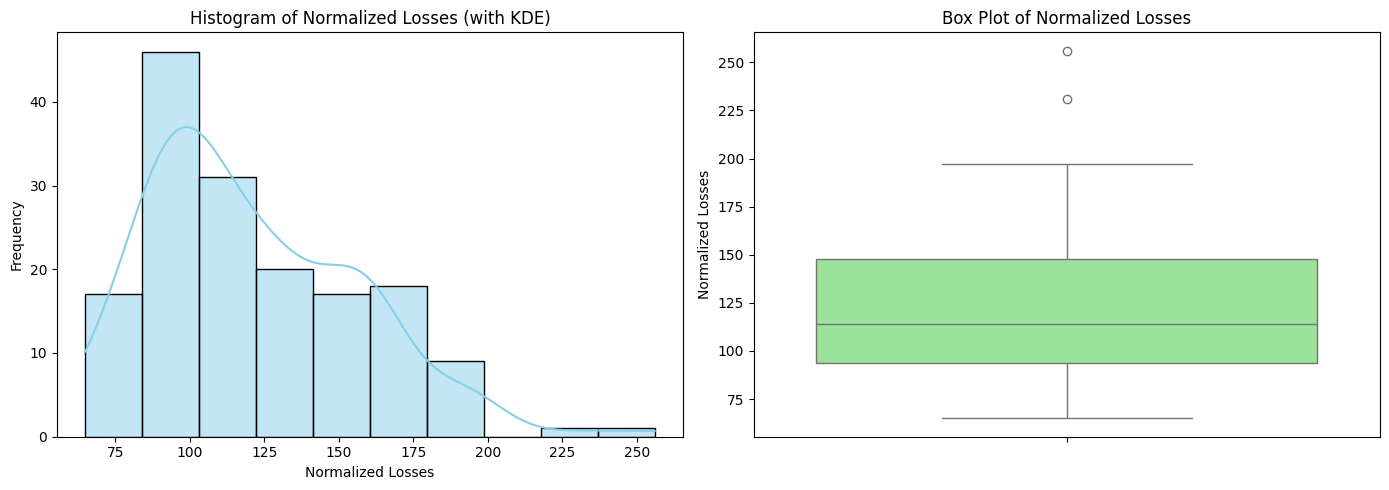

In [54]:
# --- Step 13: Visualizing 'normalized-losses' ---

import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size for two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Histogram with KDE ---
sns.histplot(
    df_clean['normalized-losses'],
    kde=True,
    color='skyblue',    # Custom color for histogram
    edgecolor='black',  # Black edges for clarity
    ax=axes[0]
)
axes[0].set_title('Histogram of Normalized Losses (with KDE)', fontsize=12)
axes[0].set_xlabel('Normalized Losses')
axes[0].set_ylabel('Frequency')

# --- Plot 2: Box Plot ---
sns.boxplot(
    y=df_clean['normalized-losses'],
    color='lightgreen',  # Custom color for boxplot
    ax=axes[1]
)
axes[1].set_title('Box Plot of Normalized Losses', fontsize=12)
axes[1].set_ylabel('Normalized Losses')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [55]:
# --- Step 14: Removing Specific Outliers in 'normalized-losses' ---

# Store the initial number of rows for reference
initial_rows = len(df_clean)
print(f"Initial number of rows: {initial_rows}")

# Define the indices of rows identified as outliers
outlier_indices = [190, 106]

# Filter out indices that are not present in the current DataFrame index
indices_to_drop = [index for index in outlier_indices if index in df_clean.index]

# Drop the specified outlier rows from the DataFrame
if indices_to_drop:
    df_clean.drop(index=indices_to_drop, inplace=True)
    # Calculate and print the number of rows removed
    rows_dropped = initial_rows - len(df_clean)
    print(f"Number of rows dropped: {rows_dropped}")
    print(f"Final number of rows: {len(df_clean)}")

    # Verify the outliers are removed by checking the top 3 'normalized-losses' values
    print("\nTop 3 'normalized-losses' values after outlier removal:")
    print(df_clean['normalized-losses'].sort_values(ascending=False).head(3))
else:
    print("None of the specified outlier indices were found in the DataFrame.")
    print(f"Final number of rows: {len(df_clean)}")

Initial number of rows: 195
Number of rows dropped: 2
Final number of rows: 193

Top 3 'normalized-losses' values after outlier removal:
178    197.0
179    197.0
104    194.0
Name: normalized-losses, dtype: float64


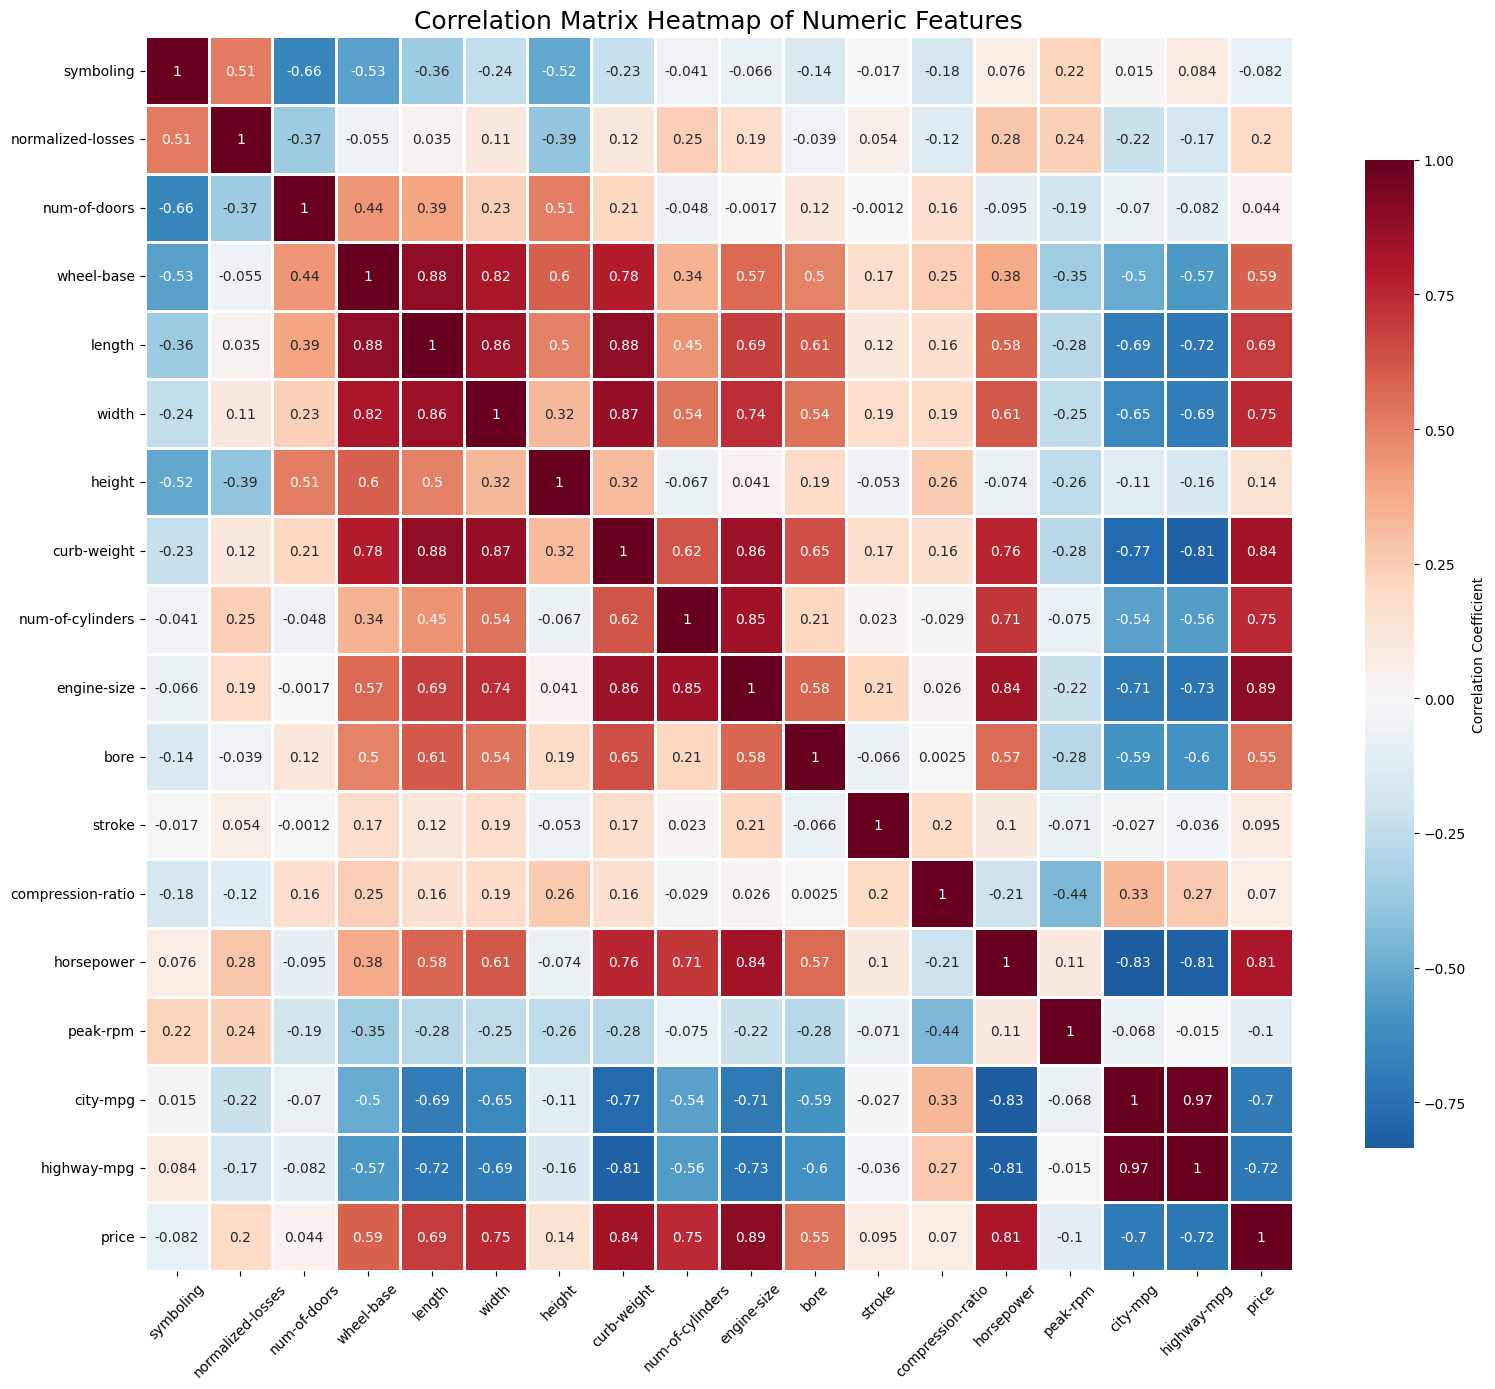

In [56]:
# --- Step 15: Correlation Matrix Heatmap ---

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select all numeric columns for correlation analysis
df_numeric = df_clean.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = df_numeric.corr()

# Set up the figure size
plt.figure(figsize=(16, 14))

# Draw the heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,               # Show correlation values on the heatmap
    cmap='RdBu_r',            # Diverging palette: red for negative, blue for positive
    center=0,                 # Center the colormap at 0
    linewidths=0.8,           # Line width between cells
    linecolor='white',        # Color of the lines
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}  # Colorbar customization
)

# Add title
plt.title('Correlation Matrix Heatmap of Numeric Features', fontsize=18)
plt.xticks(rotation=45)       # Rotate x-axis labels for readability
plt.yticks(rotation=0)        # Keep y-axis labels horizontal
plt.tight_layout()
plt.show()

In [57]:
# --- Step 16: Pairwise Correlation Analysis ---

# Correlation between 'symboling' (risk rating) and 'normalized-losses'
corr_symboling_losses = df_clean['symboling'].corr(df_clean['normalized-losses'])
print("--- Correlation between 'symboling' and 'normalized-losses' ---")
print(f"Correlation Coefficient (r): {corr_symboling_losses:.2f}\n")

# Correlation between 'normalized-losses' and 'height'
corr_losses_height = df_clean['normalized-losses'].corr(df_clean['height'])
print("--- Correlation between 'normalized-losses' and 'height' ---")
print(f"Correlation Coefficient (r): {corr_losses_height:.2f}")


--- Correlation between 'symboling' and 'normalized-losses' ---
Correlation Coefficient (r): 0.51

--- Correlation between 'normalized-losses' and 'height' ---
Correlation Coefficient (r): -0.39


In [58]:
# --- Step 17: Impute Missing 'normalized-losses' Using Linear Regression ---

from sklearn.linear_model import LinearRegression
import pandas as pd

# Split the data into rows with known and missing 'normalized-losses'
df_train = df_clean.dropna(subset=['normalized-losses'])
df_predict = df_clean[df_clean['normalized-losses'].isnull()]

missing_count = len(df_predict)
print(f"Number of 'normalized-losses' values to impute: {missing_count}")

if missing_count > 0:
    # Define features and target
    X_train = df_train[['symboling', 'height']]
    y_train = df_train['normalized-losses']
    X_predict = df_predict[['symboling', 'height']]

    # Train Linear Regression model
    lr_imputer = LinearRegression()
    lr_imputer.fit(X_train, y_train)

    # Predict missing values and update the DataFrame
    df_clean.loc[df_clean['normalized-losses'].isnull(), 'normalized-losses'] = lr_imputer.predict(X_predict)

    # Verify imputation
    remaining_nan = df_clean['normalized-losses'].isnull().sum()
    print(f"Imputation successful. Remaining NaN count: {remaining_nan}")
else:
    print("No missing 'normalized-losses' values found. Imputation skipped.")

# Final DataFrame overview
df_clean.info()

Number of 'normalized-losses' values to impute: 35
Imputation successful. Remaining NaN count: 0
<class 'pandas.core.frame.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          193 non-null    int64  
 1   normalized-losses  193 non-null    float64
 2   make               193 non-null    object 
 3   fuel-type          193 non-null    object 
 4   aspiration         193 non-null    object 
 5   num-of-doors       193 non-null    int64  
 6   body-style         193 non-null    object 
 7   drive-wheels       193 non-null    object 
 8   engine-location    193 non-null    object 
 9   wheel-base         193 non-null    float64
 10  length             193 non-null    float64
 11  width              193 non-null    float64
 12  height             193 non-null    float64
 13  curb-weight        193 non-null    int64  
 14  engine-type        193 non-nul

In [59]:
# --- Step 18: Updated Descriptive Statistics for 'normalized-losses' ---

# Calculate mean and standard deviation (NaN values are ignored automatically)
losses_mean = df_clean['normalized-losses'].mean()
losses_std = df_clean['normalized-losses'].std()

# Display the updated statistics
print("--- Updated Descriptive Statistics for 'normalized-losses' ---")
print(f"Mean: {losses_mean:.2f}")
print(f"Standard Deviation: {losses_std:.2f}")


--- Updated Descriptive Statistics for 'normalized-losses' ---
Mean: 120.54
Standard Deviation: 31.38


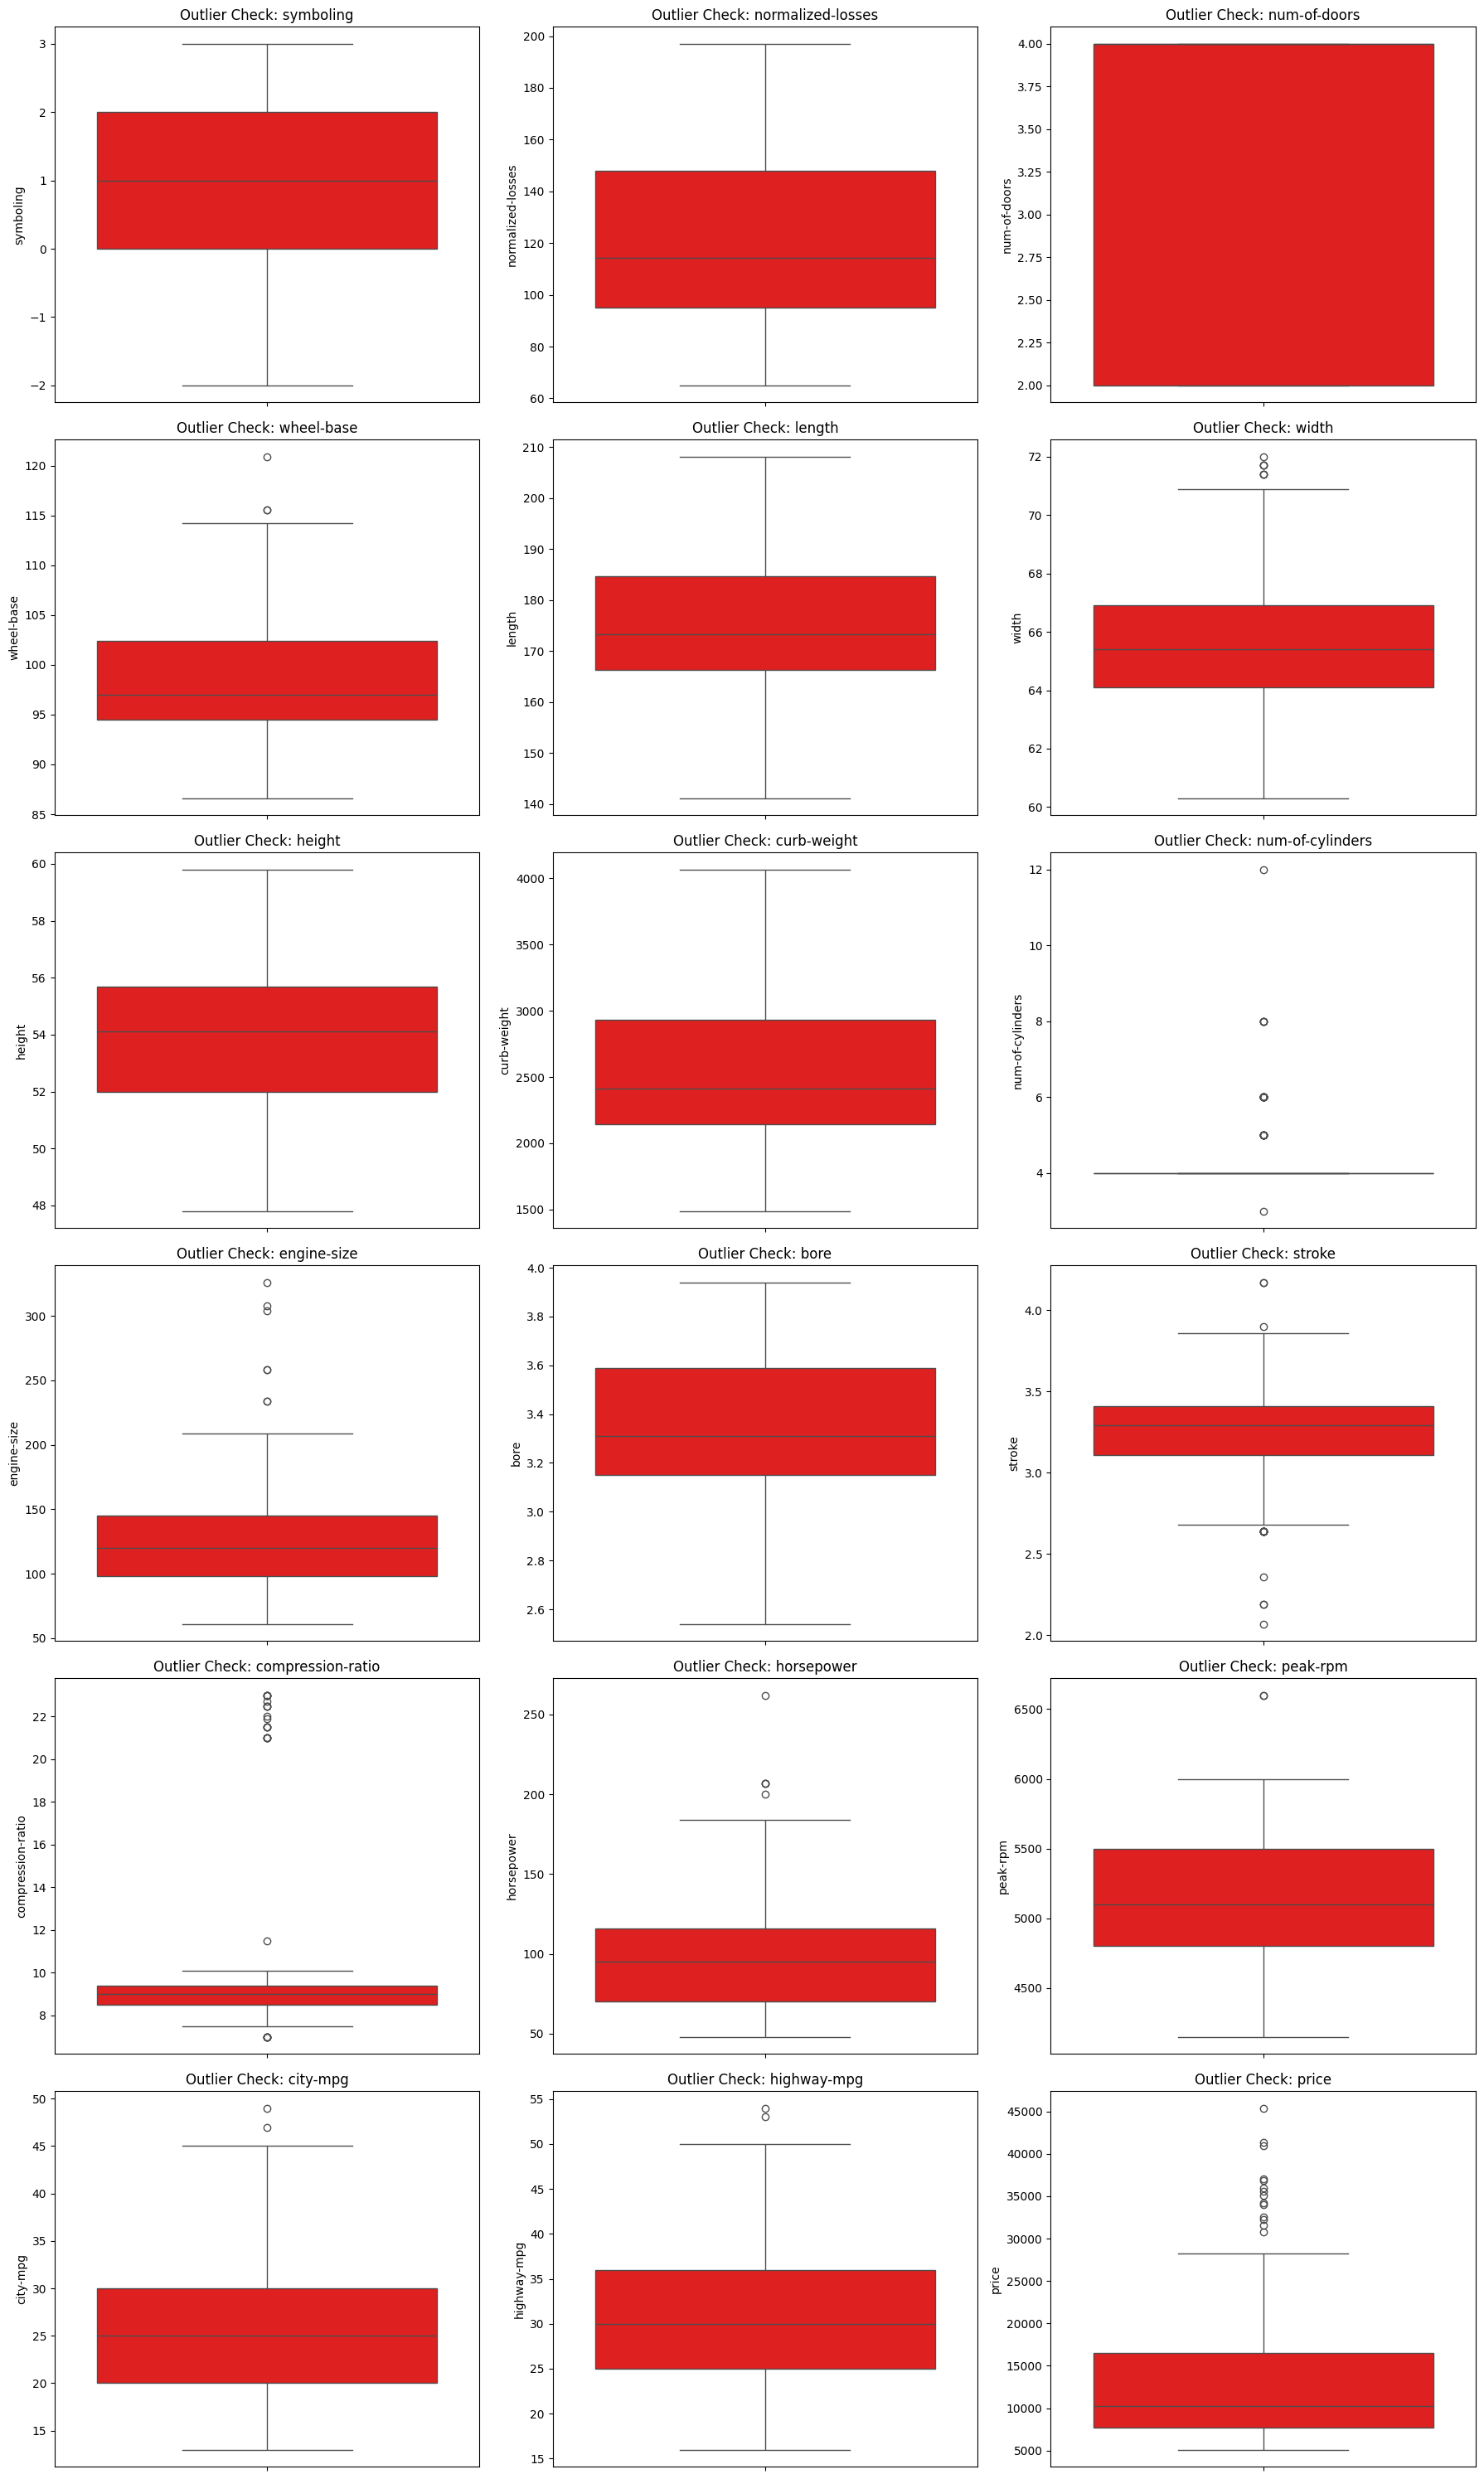

In [60]:
# --- Step 19: Box Plots for Outlier Detection in All Numeric Features ---

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select all numerical columns
df_numeric = df_clean.select_dtypes(include=np.number)

# Determine the number of plots needed
n_cols = df_numeric.shape[1]
n_rows = (n_cols + 2) // 3  # 3 plots per row

# Set up the figure and axes for subplots
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
axes = axes.flatten()  # Flatten for easy iteration

# Create a box plot for each numeric column
for i, col in enumerate(df_numeric.columns):
    sns.boxplot(y=df_numeric[col], ax=axes[i], color='red')
    axes[i].set_title(f'Outlier Check: {col}', fontsize=12)
    axes[i].set_ylabel(col)

# Remove any unused subplots
for j in range(n_cols, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and display
plt.tight_layout()
plt.show()

In [61]:
# --- Step 20: Correlation of All Numeric Features with 'price' ---

import numpy as np

# Select all numeric columns
df_numeric = df_clean.select_dtypes(include=np.number)

# Calculate correlation of all numeric columns with 'price'
correlation_with_price = df_numeric.corr()['price'].sort_values(ascending=False)

# Sort by absolute correlation to see the strongest relationships, ignoring direction
strongest_correlations = correlation_with_price.iloc[1:].abs().sort_values(ascending=False)
strongest_correlations = correlation_with_price.loc[strongest_correlations.index]

# Display the results rounded to 2 decimal places
print("--- Correlation of All Features with 'price' (Sorted by Strength) ---")
print(strongest_correlations.round(2))


--- Correlation of All Features with 'price' (Sorted by Strength) ---
engine-size          0.89
curb-weight          0.84
horsepower           0.81
width                0.75
num-of-cylinders     0.75
highway-mpg         -0.72
city-mpg            -0.70
length               0.69
wheel-base           0.59
bore                 0.55
height               0.14
normalized-losses    0.13
peak-rpm            -0.10
stroke               0.09
symboling           -0.08
compression-ratio    0.07
num-of-doors         0.04
Name: price, dtype: float64


In [62]:
# --- Step 21: One-Hot Encoding of Categorical Variables ---
# ================================

import pandas as pd

# Identify all categorical columns (object dtype)
categorical_cols = df_clean.select_dtypes(include=['object']).columns
print(f"Categorical columns to be one-hot encoded: {categorical_cols.tolist()}")

# Apply One-Hot Encoding
# drop_first=True avoids the dummy variable trap (removes one category per feature)
df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Verify the transformation
print(f"\nDataFrame shape after One-Hot Encoding: {df_clean.shape}")
df_clean.info()

Categorical columns to be one-hot encoded: ['make', 'fuel-type', 'aspiration', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'fuel-system']

DataFrame shape after One-Hot Encoding: (193, 57)
<class 'pandas.core.frame.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 57 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   symboling             193 non-null    int64  
 1   normalized-losses     193 non-null    float64
 2   num-of-doors          193 non-null    int64  
 3   wheel-base            193 non-null    float64
 4   length                193 non-null    float64
 5   width                 193 non-null    float64
 6   height                193 non-null    float64
 7   curb-weight           193 non-null    int64  
 8   num-of-cylinders      193 non-null    int64  
 9   engine-size           193 non-null    int64  
 10  bore                  193 non-null    float64
 11  stroke                1

In [63]:
# --- Step 22: One-Hot Encoding for 'num-of-doors' ---

import pandas as pd

# Ensure 'num-of-doors' is treated as a categorical variable
df_clean['num-of-doors'] = df_clean['num-of-doors'].astype('object')

# Apply One-Hot Encoding to 'num-of-doors' only
# drop_first=True avoids the Dummy Variable Trap
df_clean = pd.get_dummies(df_clean, columns=['num-of-doors'], drop_first=True)

# Verify the new columns created after encoding
print("--- New Columns After Encoding 'num-of-doors' ---")
print(df_clean.filter(like='num-of-doors_').head())

# Display the updated DataFrame shape
print(f"\nDataFrame shape after 'num-of-doors' encoding: {df_clean.shape}")


--- New Columns After Encoding 'num-of-doors' ---
   num-of-doors_4
0           False
1           False
2           False
3            True
4            True

DataFrame shape after 'num-of-doors' encoding: (193, 57)


In [64]:
df_clean.head(3)

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,bore,...,engine-type_ohc,engine-type_ohcf,engine-type_ohcv,fuel-system_2bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi,num-of-doors_4
0,3,161.043452,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,False,False,False,False,False,False,True,False,False,False
1,3,161.043452,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,False,False,False,False,False,False,True,False,False,False
2,1,127.301529,94.5,171.2,65.5,52.4,2823,6,152,2.68,...,False,False,True,False,False,False,True,False,False,False


In [65]:
# --- Step 23: Final Correlation of All Features with 'price' ---

import numpy as np

# Since all categorical columns are encoded, the DataFrame is fully numeric
correlation_with_price = df_clean.corr()['price']

# Sort features by absolute correlation to identify strongest predictors
strongest_correlations = correlation_with_price.iloc[1:].abs().sort_values(ascending=False)
strongest_correlations = correlation_with_price.loc[strongest_correlations.index]

# Display the sorted correlations rounded to 2 decimal places
print("--- Final Correlation of All Features with 'price' (Sorted by Strength) ---")
print(strongest_correlations.round(3))

--- Final Correlation of All Features with 'price' (Sorted by Strength) ---
price                   1.000
engine-size             0.889
curb-weight             0.836
horsepower              0.812
width                   0.754
num-of-cylinders        0.747
highway-mpg            -0.716
city-mpg               -0.703
length                  0.695
drive-wheels_rwd        0.648
drive-wheels_fwd       -0.603
wheel-base              0.586
bore                    0.546
make_mercedes-benz      0.526
fuel-system_mpfi        0.523
fuel-system_2bbl       -0.507
engine-type_ohcv        0.396
engine-type_ohc        -0.338
make_jaguar             0.333
make_bmw                0.332
engine-location_rear    0.332
make_porsche            0.328
body-style_hatchback   -0.305
body-style_hardtop      0.231
make_toyota            -0.185
aspiration_turbo        0.179
make_honda             -0.168
make_subaru            -0.150
body-style_sedan        0.148
make_volvo              0.147
make_dodge             -

In [66]:
# --- Step 24: Drop Low-Correlation Features ---

import numpy as np

# Calculate correlation of all features with 'price'
correlation_with_price = df_clean.corr()['price']

# Identify features with absolute correlation < 0.3 (excluding 'price')
columns_to_drop = correlation_with_price[
    (correlation_with_price.abs() < 0.3) & (correlation_with_price.index != 'price')
].index.tolist()

# Display dropped columns and initial column count
print("--- Columns Dropped (|Correlation| < 0.3) ---")
print(columns_to_drop)
print(f"\nInitial number of columns: {df_clean.shape[1] + len(columns_to_drop)}")

# Drop the identified low-correlation features
df_clean.drop(columns=columns_to_drop, inplace=True)

# Display updated DataFrame info
print(f"\nFinal number of columns: {df_clean.shape[1]}")
print("\nUpdated DataFrame Info:")
df_clean.info()

--- Columns Dropped (|Correlation| < 0.3) ---
['symboling', 'normalized-losses', 'height', 'stroke', 'compression-ratio', 'peak-rpm', 'make_audi', 'make_chevrolet', 'make_dodge', 'make_honda', 'make_isuzu', 'make_mazda', 'make_mercury', 'make_mitsubishi', 'make_nissan', 'make_peugot', 'make_plymouth', 'make_saab', 'make_subaru', 'make_toyota', 'make_volkswagen', 'make_volvo', 'fuel-type_gas', 'aspiration_turbo', 'body-style_hardtop', 'body-style_sedan', 'body-style_wagon', 'engine-type_l', 'engine-type_ohcf', 'fuel-system_idi', 'fuel-system_mfi', 'fuel-system_spdi', 'fuel-system_spfi', 'num-of-doors_4']

Initial number of columns: 91

Final number of columns: 23

Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   wheel-base            193 non-null    float64
 1   length                193 non-null    float64


In [67]:
# --- Step 25: Final Correlation of Features with 'price' ---

import numpy as np

# Since all categorical columns are encoded, the DataFrame is fully numeric
correlation_with_price = df_clean.corr()['price']

# Sort features by absolute correlation (excluding 'price') to identify strongest predictors
strongest_correlations = correlation_with_price.drop('price').abs().sort_values(ascending=False)
strongest_correlations = correlation_with_price.loc[strongest_correlations.index]

# Display the sorted correlations rounded to 2 decimal places
print("--- Final Correlation of All Features with 'price' (Sorted by Strength) ---")
print(strongest_correlations.round(2))

--- Final Correlation of All Features with 'price' (Sorted by Strength) ---
engine-size             0.89
curb-weight             0.84
horsepower              0.81
width                   0.75
num-of-cylinders        0.75
highway-mpg            -0.72
city-mpg               -0.70
length                  0.69
drive-wheels_rwd        0.65
drive-wheels_fwd       -0.60
wheel-base              0.59
bore                    0.55
make_mercedes-benz      0.53
fuel-system_mpfi        0.52
fuel-system_2bbl       -0.51
engine-type_ohcv        0.40
engine-type_ohc        -0.34
make_jaguar             0.33
make_bmw                0.33
engine-location_rear    0.33
make_porsche            0.33
body-style_hatchback   -0.31
Name: price, dtype: float64


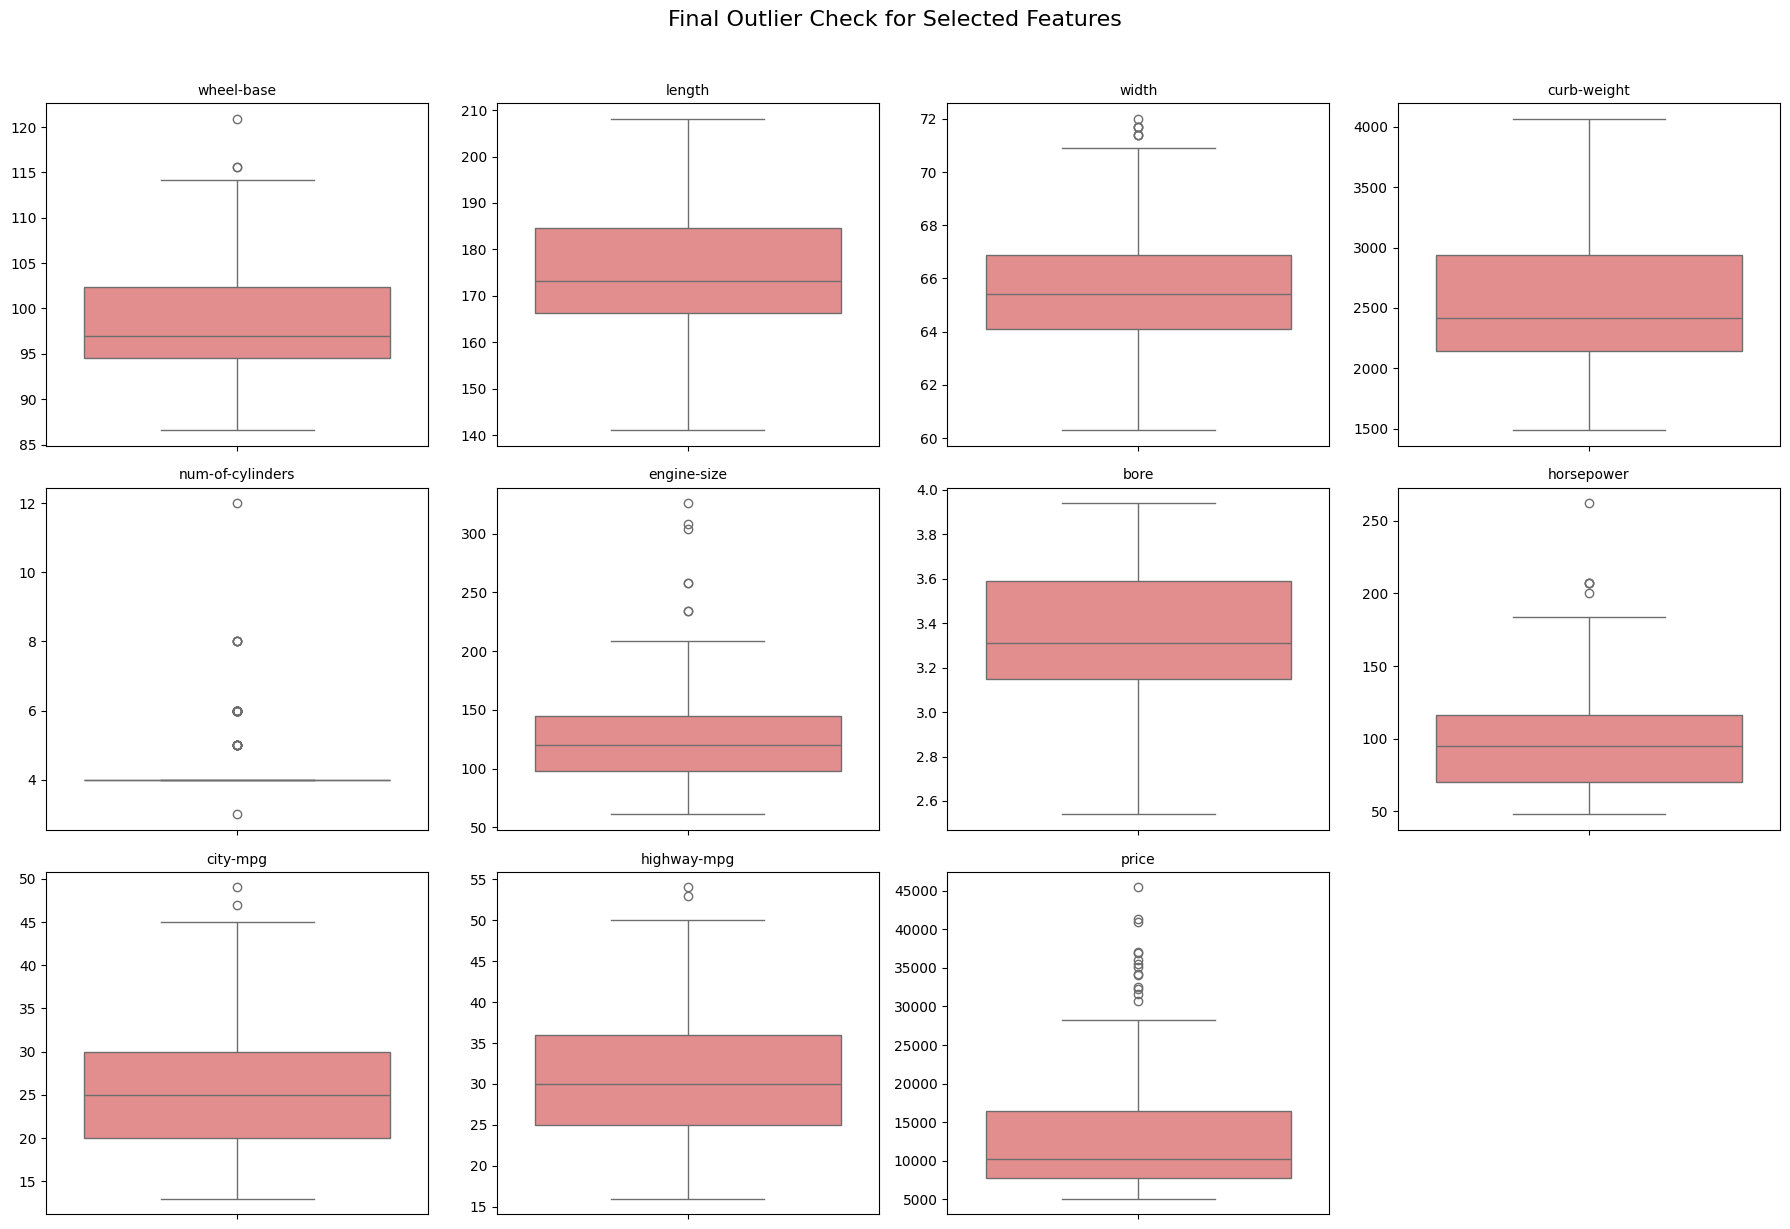

In [68]:
# --- Step 26: Box Plots for Outlier Detection in Final Features ---

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select all numeric columns in the final trimmed DataFrame
df_numeric_final = df_clean.select_dtypes(include=np.number)

# Determine the layout for subplots (4 plots per row)
n_cols = df_numeric_final.shape[1]
n_rows = (n_cols + 3) // 4  # Ceiling division

# Set up the figure and axes
fig, axes = plt.subplots(n_rows, 4, figsize=(18, 4 * n_rows))
axes = axes.flatten()  # Flatten for easy iteration

# Create a box plot for each numerical column
for i, col in enumerate(df_numeric_final.columns):
    sns.boxplot(y=df_numeric_final[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('')  # Remove y-label for cleaner layout

# Remove any unused subplots
for j in range(n_cols, len(axes)):
    fig.delaxes(axes[j])

# Add a super title for the figure
plt.suptitle('Final Outlier Check for Selected Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [69]:
# --- Step 27: Descriptive Statistics for the Final 'price' Column ---

# Calculate mean and standard deviation (NaN values are automatically ignored)
price_mean = df_clean['price'].mean()
price_std = df_clean['price'].std()

# Display the results with formatted output
print("--- Descriptive Statistics for Final 'price' Column ---")
print(f"Mean Price: ${price_mean:,.2f}")
print(f"Standard Deviation (SD) of Price: ${price_std:,.2f}")


--- Descriptive Statistics for Final 'price' Column ---
Mean Price: $13,238.26
Standard Deviation (SD) of Price: $8,086.20


In [70]:
# --- Step 28: Train-Test Split (80% Train / 20% Test) ---

from sklearn.model_selection import train_test_split
import pandas as pd

# Separate features (X) and target variable (y)
X = df_clean.drop('price', axis=1)
y = df_clean['price']

# Perform the train-test split
# test_size=0.2 → 20% of data for testing
# random_state=42 → ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Verify the split
print("--- Data Split Verification ---")
print(f"Total number of rows: {len(df_clean)}")
print(f"X_train shape (Training Features): {X_train.shape}")
print(f"X_test shape (Testing Features): {X_test.shape}")
print(f"y_train shape (Training Target): {y_train.shape}")
print(f"y_test shape (Testing Target): {y_test.shape}")

--- Data Split Verification ---
Total number of rows: 193
X_train shape (Training Features): (154, 22)
X_test shape (Testing Features): (39, 22)
y_train shape (Training Target): (154,)
y_test shape (Testing Target): (39,)


In [71]:
# --- Step 29: Feature Scaling and PCA Transformation (3 Components) ---

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# Feature Scaling
scaler = StandardScaler()
# Fit on training data and transform both training and testing sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use the same scaler

# PCA Transformation (reduce to 3 components)
pca = PCA(n_components=3)
pca.fit(X_train_scaled)  # Fit PCA on scaled training data

# Transform both training and testing data
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Verification of PCA results
print("--- PCA Transformation Verification ---")
print(f"Original Feature Count: {X_train.shape[1]}")
print(f"PCA Components Count: {pca.n_components_}")
print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"X_test_pca shape: {X_test_pca.shape}")

--- PCA Transformation Verification ---
Original Feature Count: 22
PCA Components Count: 3
X_train_pca shape: (154, 3)
X_test_pca shape: (39, 3)


In [72]:
# --- Step 30: Train Linear Regression on PCA-Transformed Features ---

from sklearn.linear_model import LinearRegression
import numpy as np

# Instantiate the Linear Regression Model
linear_model = LinearRegression()

# Train the model using the PCA-transformed training data
# Note: X_train_pca has 3 components
linear_model.fit(X_train_pca, y_train)

# Make predictions on both training and testing sets
y_train_pred = linear_model.predict(X_train_pca)
y_test_pred = linear_model.predict(X_test_pca)

# Display model details
print("--- Linear Regression Model Trained ---")

# Intercept
print("\nModel Intercept (Baseline Price):")
print(f"${linear_model.intercept_:.2f}")

# Coefficients for the 3 PCA components
print("\nCoefficients for the 3 PCA Components:")
for i, coef in enumerate(linear_model.coef_):
    print(f" Component {i+1}: {coef:,.2f}")

# Predictions (y_train_pred and y_test_pred) are now available for evaluation

--- Linear Regression Model Trained ---

Model Intercept (Baseline Price):
$12758.82

Coefficients for the 3 PCA Components:
 Component 1: 1,934.89
 Component 2: 755.58
 Component 3: -153.92


In [73]:
# --- Step 31: Evaluate Linear Regression Model (R² and Adjusted R²) ---

from sklearn.metrics import r2_score
import numpy as np

# Calculate R-squared (R²) for the test set
r_squared = r2_score(y_test, y_test_pred)

# Define parameters for Adjusted R²
n = X_test_pca.shape[0]  # Number of observations in the test set
k = X_test_pca.shape[1]  # Number of predictors (PCA components = 3)

# alculate Adjusted R-squared
adjusted_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - k - 1)

# Display performance metrics
print("--- Model Performance Metrics (Test Set) ---")
print(f"Standard R-squared (R²): {r_squared:.4f}")
print(f"Adjusted R-squared (Adjusted R²): {adjusted_r_squared:.4f}")

--- Model Performance Metrics (Test Set) ---
Standard R-squared (R²): 0.7843
Adjusted R-squared (Adjusted R²): 0.7658


In [74]:
# --- Step 32: Predict Price for a New Car ---

import pandas as pd
import numpy as np

# Define raw data for the new car
# Only include features present in the final processed dataset
new_car_raw_data = {
    'wheel-base': 87.65,
    'length': 170.4,
    'width': 70,
    'height': 59.7,
    'curb-weight': 2300,
    'engine-size': 96,
    'bore': 3.00,
    'stroke': 3.25,
    'compression-ratio': 9.0,
    'horsepower': 70.0,
    'peak-rpm': 5200.0,
    'symboling': 2,              # Risk rating
    'normalized-losses': 160.0,  # Imputed value
    'make': 'bmw',             # Categorical
    'fuel-type': 'gas',           # Categorical
    'aspiration': 'turbo',          # Categorical
    'num-of-doors': 4,            # Categorical
    'body-style': 'sedan',        # Categorical
    'drive-wheels': 'fwd',        # Categorical
    'engine-location': 'front',   # Categorical
    'engine-type': 'dohc',         # Categorical
    'num-of-cylinders': 'four',   # Categorical
    'fuel-system': 'mpfi'         # Categorical
}

# Convert raw data into a single-row DataFrame
df_new_raw = pd.DataFrame([new_car_raw_data])

# Apply One-Hot Encoding (drop_first=True) to match training data
df_new_encoded = pd.get_dummies(df_new_raw, drop_first=True)

# Align the new car features with the training features
# Any missing dummy columns are filled with 0
X_new_car_final = df_new_encoded.reindex(columns=X_train.columns, fill_value=0)

# Scale the features using the fitted StandardScaler
X_new_scaled = scaler.transform(X_new_car_final)

# Apply PCA transformation using the fitted PCA object (3 components)
X_new_pca = pca.transform(X_new_scaled)

# Predict the price using the trained Linear Regression model
predicted_price = linear_model.predict(X_new_pca)

# Display the predicted price
print("\n--- Final Predicted Price ---")
print(f"The predicted market price for the new BMW Sedan is: ${predicted_price[0]:,.2f}")



--- Final Predicted Price ---
The predicted market price for the new BMW Sedan is: $14,286.46
